In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    num_rows, num_cols, _, _ = matrices.shape
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

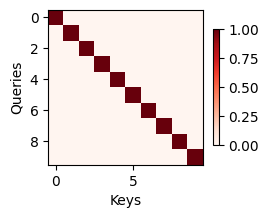

In [3]:
attention_weights = tf.reshape(tf.eye(10), (1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

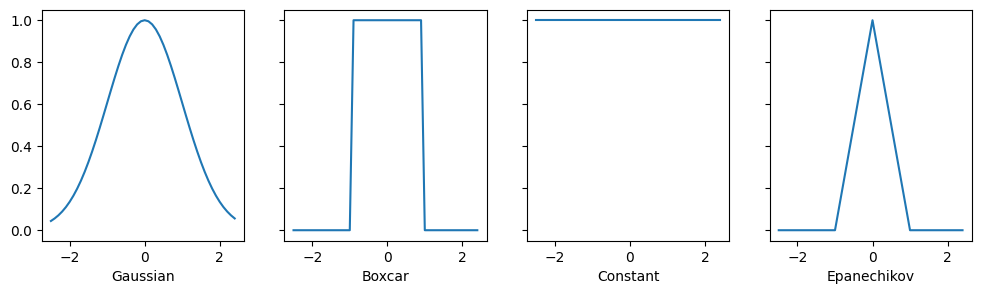

In [5]:
# Define some kernels
def gaussian(x):
    return tf.exp(-x**2 / 2)

def boxcar(x):
    return tf.abs(x) < 1.0

def constant(x):
    return 1.0 + 0 * x

def epanechikov(x):
    return tf.maximum(1 - tf.abs(x), 0)

fig, axes = plt.subplots(1, 4, sharey=True, figsize=(12, 3))

kernels = (gaussian, boxcar, constant, epanechikov)
names = ('Gaussian', 'Boxcar', 'Constant', 'Epanechikov')
x = tf.range(-2.5, 2.5, 0.1)
for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.numpy(), kernel(x).numpy())
    ax.set_xlabel(name)

plt.show()

In [6]:
def f(x):
    return 2 * tf.sin(x) + x

n = 40
x_train = tf.sort(tf.random.uniform((n,1)) * 5, 0)
y_train = f(x_train) + tf.random.normal((n, 1))
x_val = tf.range(0, 5, 0.1)
y_val = f(x_val)

In [7]:
def nadaraya_watson(x_train, y_train, x_val, kernel):
    dists = tf.reshape(x_train, (-1, 1)) - tf.reshape(x_val, (1, -1))
    # Each column/row corresponds to each query/key
    k = tf.cast(kernel(dists), tf.float32)
    # Normalization over keys for each query
    attention_w = k / tf.reduce_sum(k, 0)
    y_hat = tf.transpose(tf.transpose(y_train)@attention_w)
    return y_hat, attention_w

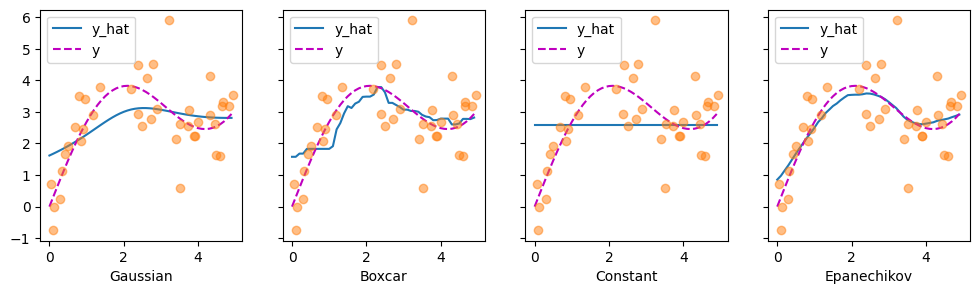

In [8]:
def plot(x_train, y_train, x_val, y_val, kernels, names, attention=False):
    fig, axes = plt.subplots(1, 4, sharey=True, figsize=(12, 3))
    for kernel, name, ax in zip(kernels, names, axes):
        y_hat, attention_w = nadaraya_watson(x_train, y_train, x_val, kernel)
        if attention:
            pcm = ax.imshow(attention_w.numpy(), cmap='Reds')
        else:
            ax.plot(x_val, y_hat)
            ax.plot(x_val, y_val, 'm--')
            ax.plot(x_train, y_train, 'o', alpha=0.5);
        ax.set_xlabel(name)
        if not attention:
            ax.legend(['y_hat', 'y'])
    if attention:
        fig.colorbar(pcm, ax=axes, shrink=0.7)

plot(x_train, y_train, x_val, y_val, kernels, names)

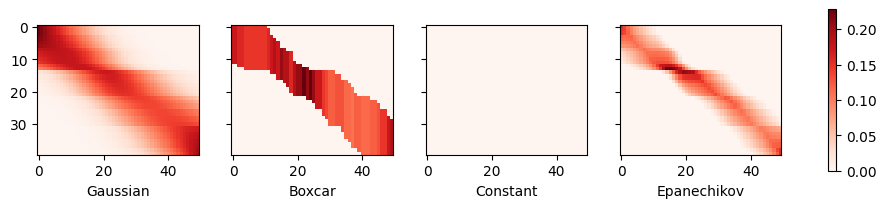

In [9]:
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)

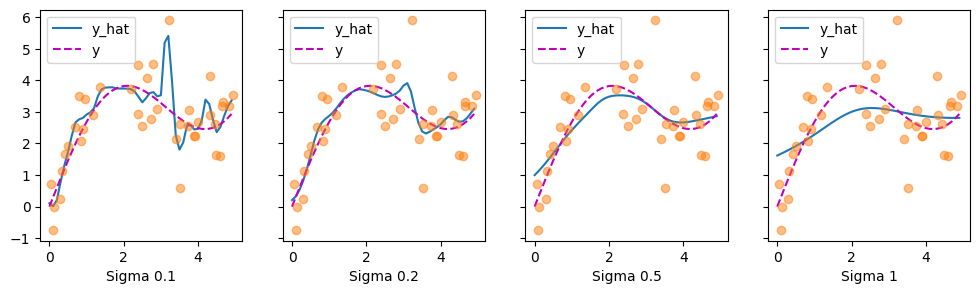

In [10]:
sigmas = (0.1, 0.2, 0.5, 1)
names = ['Sigma ' + str(sigma) for sigma in sigmas]

def gaussian_with_width(sigma):
    return (lambda x: tf.exp(-x**2 / (2*sigma**2)))

kernels = [gaussian_with_width(sigma) for sigma in sigmas]
plot(x_train, y_train, x_val, y_val, kernels, names)

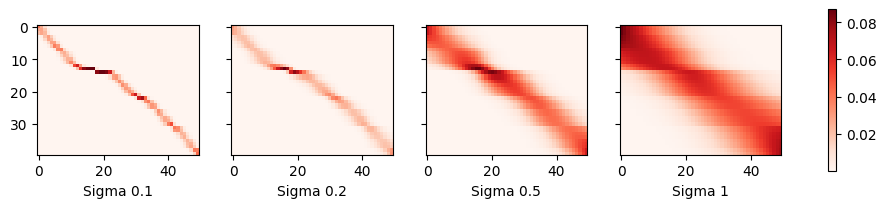

In [11]:
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)

In [12]:
def masked_softmax(X, valid_lens):  #@save
    """Perform softmax operation by masking elements on the last axis."""
    # X: 3D tensor, valid_lens: 1D or 2D tensor
    def _sequence_mask(X, valid_len, value=0):
        maxlen = X.shape[1]
        mask = tf.range(start=0, limit=maxlen, dtype=tf.float32)[
            None, :] < tf.cast(valid_len[:, None], dtype=tf.float32)

        if len(X.shape) == 3:
            return tf.where(tf.expand_dims(mask, axis=-1), X, value)
        else:
            return tf.where(mask, X, value)

    if valid_lens is None:
        return tf.nn.softmax(X, axis=-1)
    else:
        shape = X.shape
        if len(valid_lens.shape) == 1:
            valid_lens = tf.repeat(valid_lens, repeats=shape[1])

        else:
            valid_lens = tf.reshape(valid_lens, shape=-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = _sequence_mask(tf.reshape(X, shape=(-1, shape[-1])), valid_lens,
                           value=-1e6)
        return tf.nn.softmax(tf.reshape(X, shape=shape), axis=-1)

In [13]:
masked_softmax(tf.random.uniform(shape=(2, 2, 4)), tf.constant([2, 3]))

<tf.Tensor: shape=(2, 2, 4), dtype=float32, numpy=
array([[[0.652635  , 0.347365  , 0.        , 0.        ],
        [0.34046388, 0.6595361 , 0.        , 0.        ]],

       [[0.35969445, 0.37646997, 0.26383552, 0.        ],
        [0.34942898, 0.20711721, 0.4434538 , 0.        ]]], dtype=float32)>

In [15]:
Q = tf.ones((2, 3, 4))
K = tf.ones((2, 4, 6))
tf.matmul(Q, K).numpy().shape

(2, 3, 6)

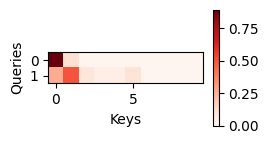

In [17]:
class DotProductAttention(tf.keras.layers.Layer):  #@save
    """Scaled dot product attention."""
    def __init__(self, dropout):
        super().__init__()
        self.dropout = tf.keras.layers.Dropout(dropout)

    # Shape of queries: (batch_size, no. of queries, d)
    # Shape of keys: (batch_size, no. of key-value pairs, d)
    # Shape of values: (batch_size, no. of key-value pairs, value dimension)
    # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
    def call(self, queries, keys, values, valid_lens=None, **kwargs):
        d = queries.shape[-1]
        scores = tf.matmul(queries, keys, transpose_b=True)/tf.math.sqrt(
            tf.cast(d, dtype=tf.float32))
        self.attention_weights = masked_softmax(scores, valid_lens)
        return tf.matmul(self.dropout(self.attention_weights, **kwargs), values)

queries = tf.random.normal(shape=(2, 1, 2))
keys = tf.random.normal(shape=(2, 10, 2))
values = tf.random.normal(shape=(2, 10, 4))
valid_lens = tf.constant([2, 6])

attention = DotProductAttention(dropout=0.5)
attention(queries, keys, values, valid_lens, training=False).shape
show_heatmaps(tf.reshape(attention.attention_weights, (1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

In [18]:
class AdditiveAttention(tf.keras.layers.Layer):  #@save
    """Additive attention."""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super().__init__(**kwargs)
        self.W_k = tf.keras.layers.Dense(num_hiddens, use_bias=False)
        self.W_q = tf.keras.layers.Dense(num_hiddens, use_bias=False)
        self.w_v = tf.keras.layers.Dense(1, use_bias=False)
        self.dropout = tf.keras.layers.Dropout(dropout)

    def call(self, queries, keys, values, valid_lens, **kwargs):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # After dimension expansion, shape of queries: (batch_size, no. of
        # queries, 1, num_hiddens) and shape of keys: (batch_size, 1, no. of
        # key-value pairs, num_hiddens). Sum them up with broadcasting
        features = tf.expand_dims(queries, axis=2) + tf.expand_dims(
            keys, axis=1)
        features = tf.nn.tanh(features)
        # There is only one output of self.w_v, so we remove the last
        # one-dimensional entry from the shape. Shape of scores: (batch_size,
        # no. of queries, no. of key-value pairs)
        scores = tf.squeeze(self.w_v(features), axis=-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # Shape of values: (batch_size, no. of key-value pairs, value
        # dimension)
        return tf.matmul(self.dropout(
            self.attention_weights, **kwargs), values)

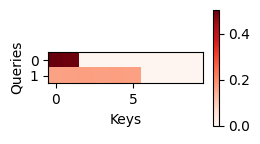

In [19]:
queries = tf.random.normal(shape=(2, 1, 20))

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8,
                              dropout=0.1)
attention(queries, keys, values, valid_lens, training=False).shape
show_heatmaps(tf.reshape(attention.attention_weights, (1, 1, 2, 10)), xlabel='Keys', ylabel='Queries')

In [21]:
class AttentionDecoder(Decoder):  #@save
    """The base attention-based decoder interface."""
    def __init__(self):
        super().__init__()

    @property
    def attention_weights(self):
        raise NotImplementedError

NameError: name 'Decoder' is not defined

In [20]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0):
        super().__init__()
        self.attention = AdditiveAttention(num_hiddens, num_hiddens,
                                               num_hiddens, dropout)
        self.embedding = tf.keras.layers.Embedding(vocab_size, embed_size)
        self.rnn = tf.keras.layers.RNN(tf.keras.layers.StackedRNNCells(
            [tf.keras.layers.GRUCell(num_hiddens, dropout=dropout)
             for _ in range(num_layers)]), return_sequences=True,
                                       return_state=True)
        self.dense = tf.keras.layers.Dense(vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        # Shape of outputs: (batch_size, num_steps, num_hiddens).
        # Length of list hidden_state is num_layers, where the shape of its
        # element is (batch_size, num_hiddens)
        outputs, hidden_state = enc_outputs
        return (tf.transpose(outputs, (1, 0, 2)), hidden_state,
                enc_valid_lens)

    def call(self, X, state, **kwargs):
        # Shape of output enc_outputs: # (batch_size, num_steps, num_hiddens)
        # Length of list hidden_state is num_layers, where the shape of its
        # element is (batch_size, num_hiddens)
        enc_outputs, hidden_state, enc_valid_lens = state
        # Shape of the output X: (num_steps, batch_size, embed_size)
        X = self.embedding(X)  # Input X has shape: (batch_size, num_steps)
        X = tf.transpose(X, perm=(1, 0, 2))
        outputs, self._attention_weights = [], []
        for x in X:
            # Shape of query: (batch_size, 1, num_hiddens)
            query = tf.expand_dims(hidden_state[-1], axis=1)
            # Shape of context: (batch_size, 1, num_hiddens)
            context = self.attention(query, enc_outputs, enc_outputs,
                                     enc_valid_lens, **kwargs)
            # Concatenate on the feature dimension
            x = tf.concat((context, tf.expand_dims(x, axis=1)), axis=-1)
            out = self.rnn(x, hidden_state, **kwargs)
            hidden_state = out[1:]
            outputs.append(out[0])
            self._attention_weights.append(self.attention.attention_weights)
        # After fully connected layer transformation, shape of outputs:
        # (batch_size, num_steps, vocab_size)
        outputs = self.dense(tf.concat(outputs, axis=1))
        return outputs, [enc_outputs, hidden_state, enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights

NameError: name 'AttentionDecoder' is not defined